In [3]:
import utils
import importlib
importlib.reload(utils)
import matplotlib.pyplot as plt
import pandas as pd

from utils import load_and_clean_data, identify_arbitrage, apply_costs, plot_arbitrage

path = r"data/2026-04-10/option_chain_nifty_2026-06-30_full_history.csv"



In [4]:
df = load_and_clean_data(path)
df = identify_arbitrage(df)
df = apply_costs(df)

In [5]:
active_df = df[df['both_legs_liquid_time_pct'] >= 100]
active_df['strike_price'].unique()

array([], dtype=int32)

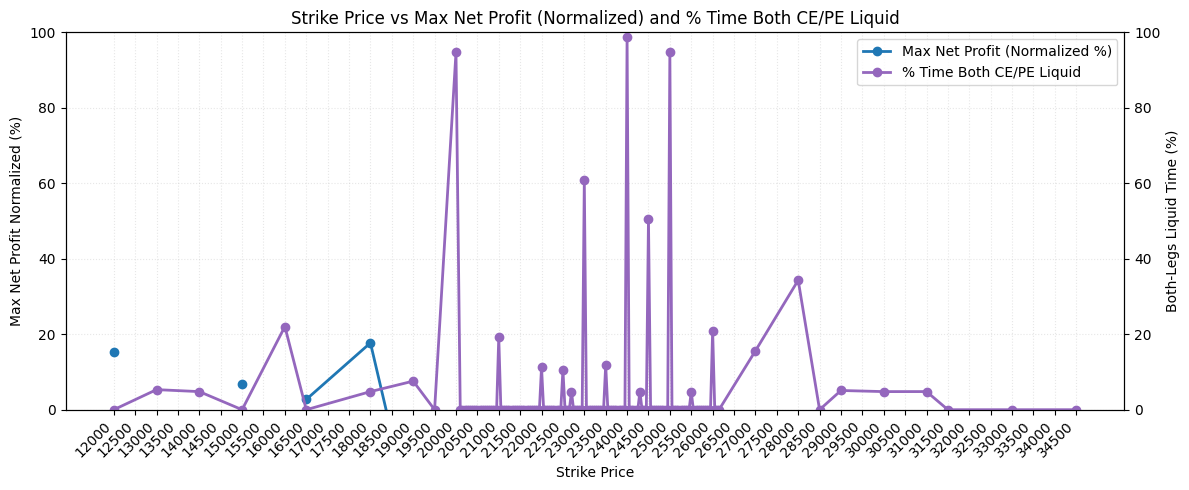

,strike_price,max_profit,max_profit_norm_pct,both_liquid_pct
0,12000,49.884655,15.252312,0.000000
1,13000,NaN,NaN,5.322339
2,14000,NaN,NaN,4.797601
3,15000,22.586685,6.905914,0.000000
4,16000,NaN,NaN,22.038981


In [6]:
utils.plot_strike_vs_max_arbitrage_and_liquidity_pct(df, trading_cost=True).head()

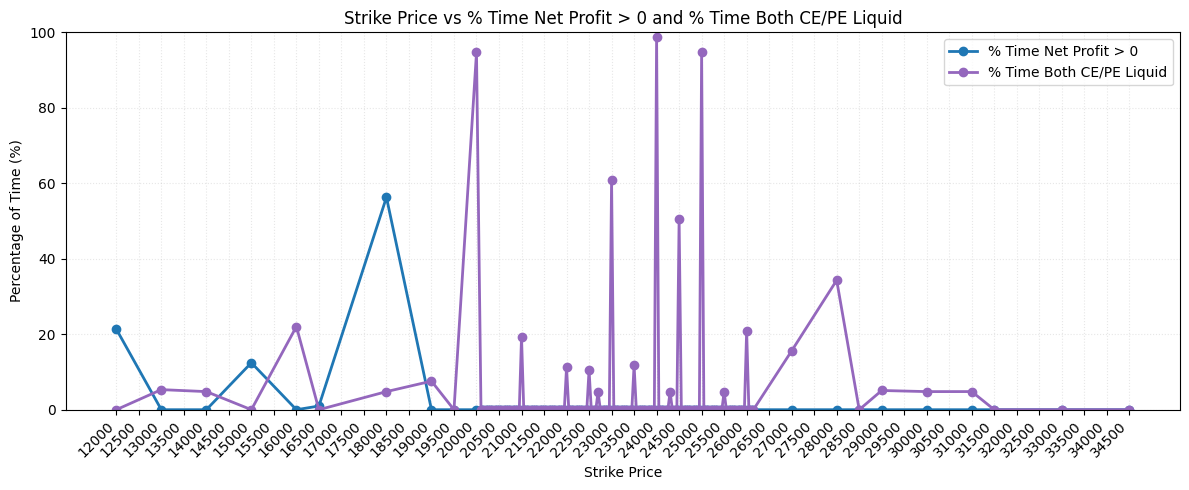

,strike_price,arbitrage_positive_pct,both_liquid_pct
0,12000,21.364318,0.000000
1,13000,0.000000,5.322339
2,14000,0.000000,4.797601
3,15000,12.443778,0.000000
4,16000,0.000000,22.038981


In [7]:
utils.plot_strike_vs_arbitrage_positive_and_liquidity_pct(df, trading_cost=True).head()

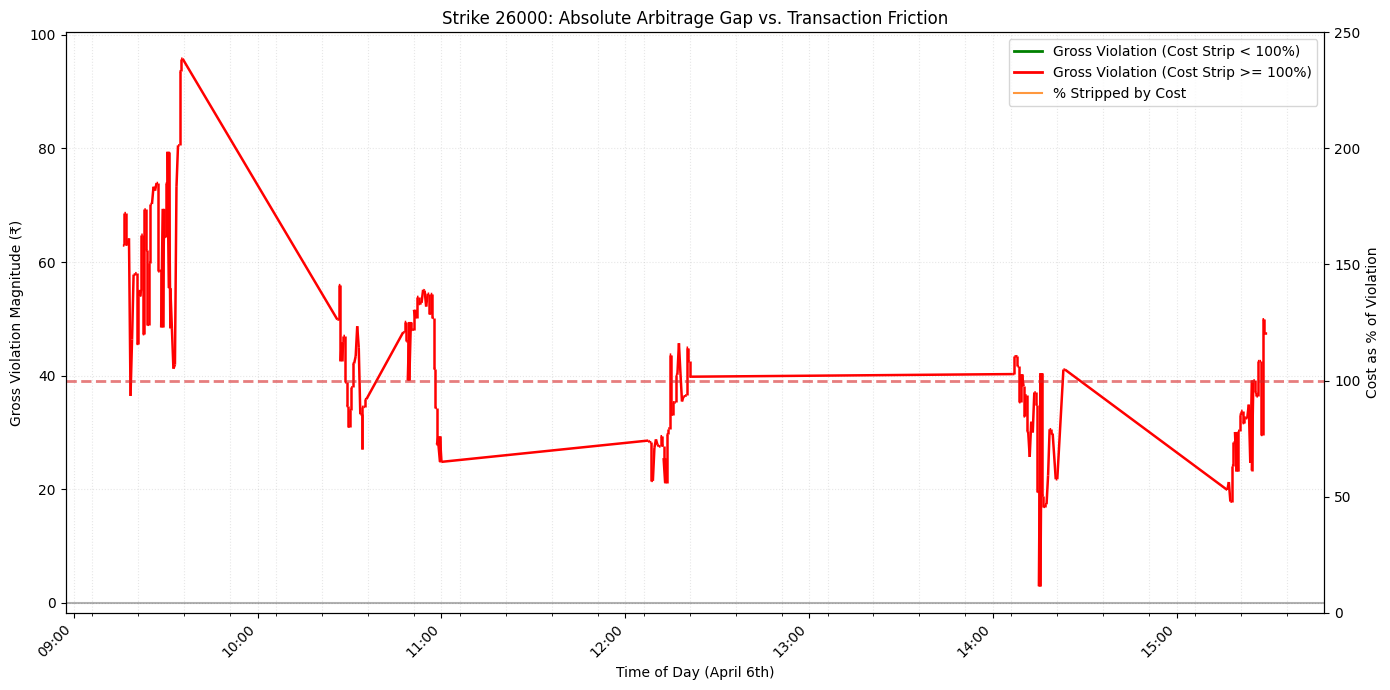

,fetch_time,abs_violation,cost,cost_stripped_pct
128,2026-04-10 09:16:00,62.918740,400.150284,635.979494
269,2026-04-10 09:16:30,62.917275,400.148672,635.991735
692,2026-04-10 09:16:30,68.617275,400.170834,583.192544
833,2026-04-10 09:17:00,68.615811,400.169222,583.202641
1256,2026-04-10 09:17:00,63.065811,400.149536,634.495188
...,...,...,...,...
390698,2026-04-10 15:28:00,49.920858,396.501047,794.259279
390839,2026-04-10 15:28:30,49.922323,396.499434,794.232746
391262,2026-04-10 15:28:30,47.422323,396.511474,836.128329
391403,2026-04-10 15:29:00,47.423787,396.509860,836.099105


In [8]:
utils.plot_strike_abs_violation_vs_cost_stripped_pct(df[df['both_legs_liquid'] == True], strike=26000)

In [9]:
importlib.reload(utils)

<module 'utils' from 'd:\\finmod\\Nifty50-PutCallParity-Arbitrage\\utils.py'>

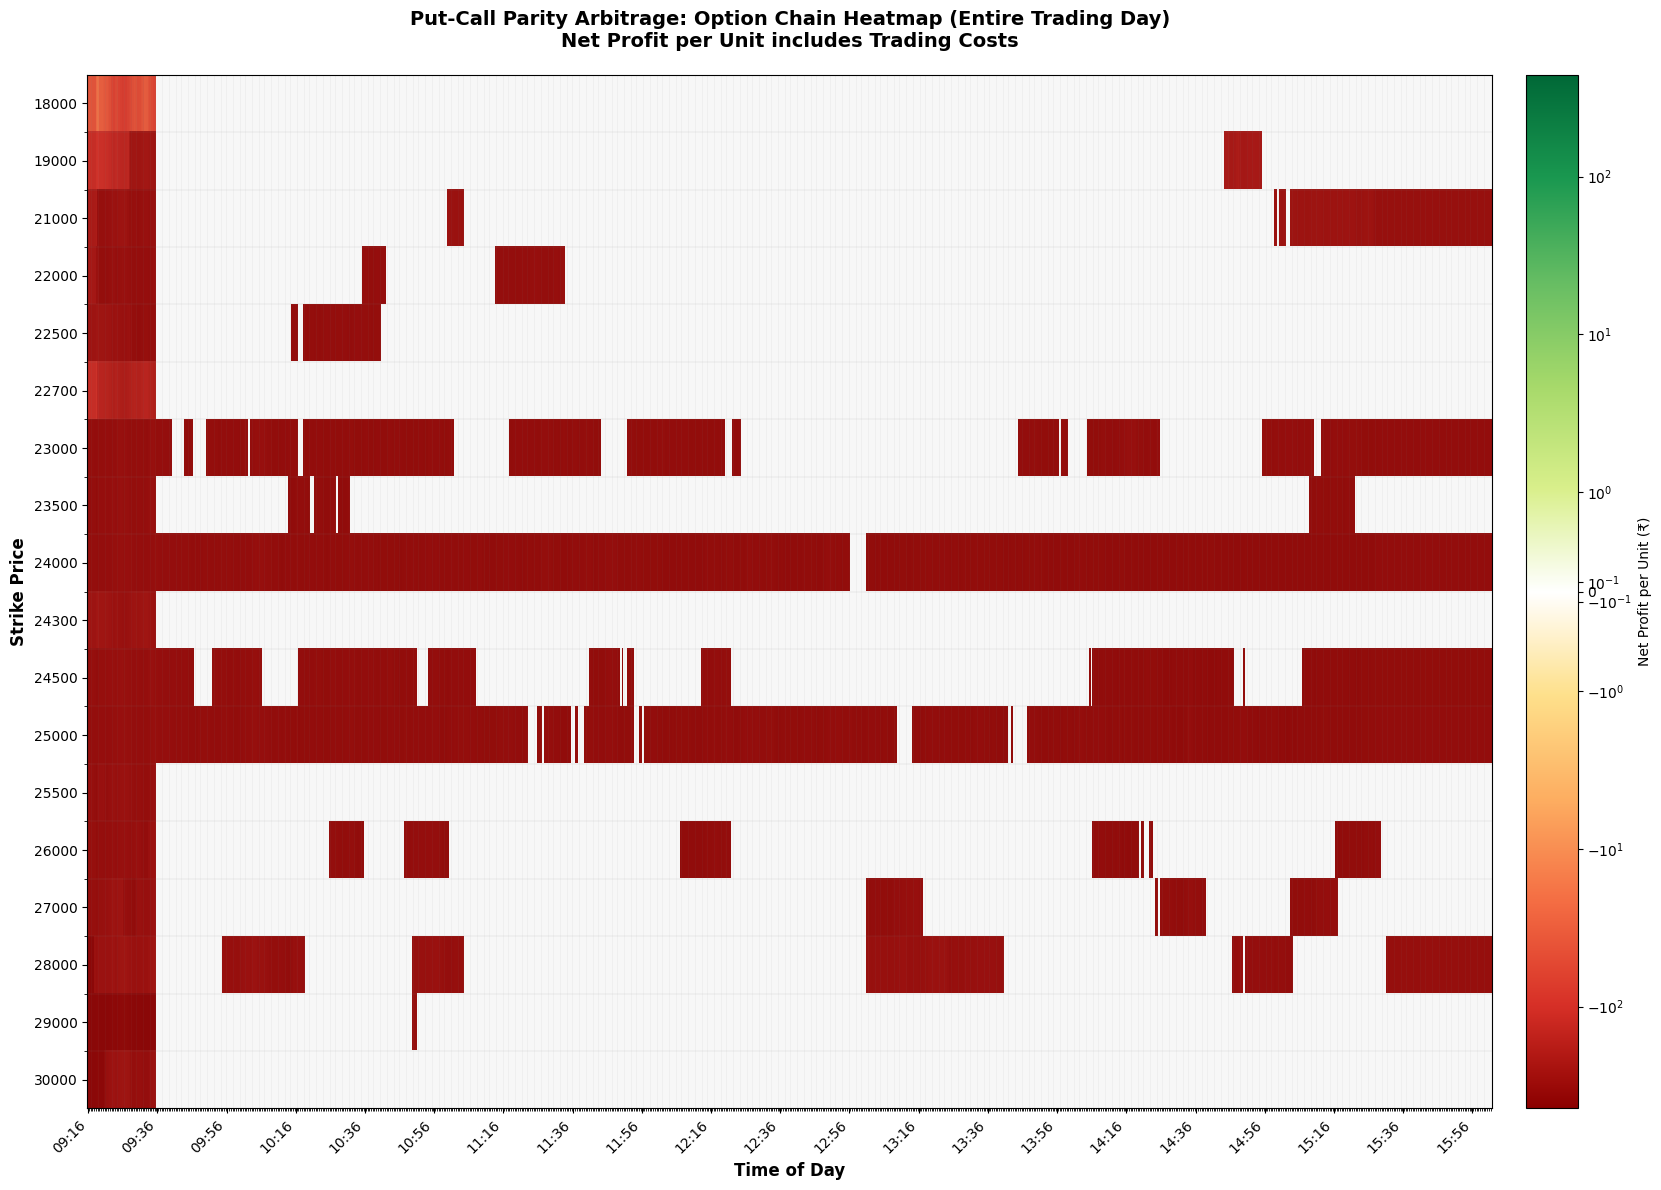

In [10]:
# COMPREHENSIVE HEATMAP: Entire Option Chain Over Entire Trading Day
# X-axis: Time of Day (09:15 to 15:30)
# Y-axis: Strike Prices (sorted)
# Color: Net Profit (Green=Profitable, Red=Loss, White=Break-even)

pivot_data = utils.plot_option_chain_heatmap_over_time(
    df[df['both_legs_liquid'] == True],  # Filter for options that were liquid at least 50% of the time
    min_liquidity=0,  # Include all data (change to e.g., 500 for more liquid options)
    trading_cost=True,
    figsize=(18, 12),
    efficiency_band_pct=0.001,  # Smaller neutral band for faster color transition
)

In [11]:
df.columns

Index(['fetch_time', 'symbol', 'expiry', 'spot_price', 'strike_price',
       'ce_growwContractId', 'ce_displayName', 'ce_longDisplayName',
       'ce_token', 'ce_marketLot', 'ce_liveData_close', 'ce_liveData_ltp',
       'ce_liveData_dayChange', 'ce_liveData_dayChangePerc', 'ce_liveData_oi',
       'ce_liveData_prevOI', 'ce_greeks_delta', 'ce_greeks_gamma',
       'ce_greeks_theta', 'ce_greeks_vega', 'ce_greeks_rho', 'ce_greeks_iv',
       'ce_greeks_pop', 'ce_markers', 'pe_growwContractId', 'pe_displayName',
       'pe_longDisplayName', 'pe_token', 'pe_marketLot', 'pe_liveData_close',
       'pe_liveData_ltp', 'pe_liveData_dayChange', 'pe_liveData_dayChangePerc',
       'pe_liveData_oi', 'pe_liveData_prevOI', 'pe_greeks_delta',
       'pe_greeks_gamma', 'pe_greeks_theta', 'pe_greeks_vega', 'pe_greeks_rho',
       'pe_greeks_iv', 'pe_greeks_pop', 'pe_markers', 'T', 'liquidity',
       'both_legs_liquid', 'both_legs_liquid_time_pct', 'market_side',
       'theoretical_side', 'violation

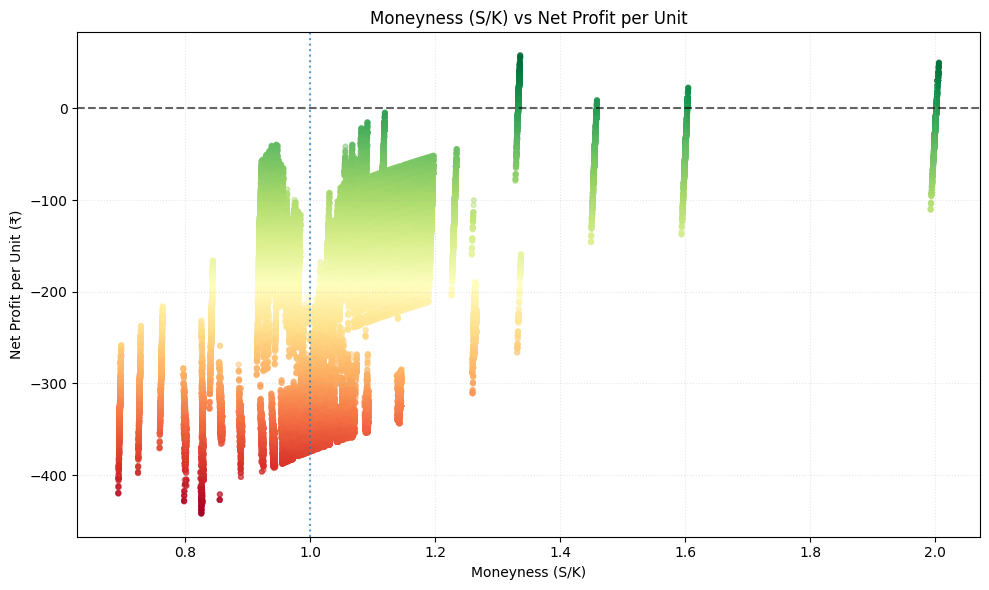

,moneyness,net_profit_per_unit
0,1.995583,-73.143964
1,1.842077,NaN
2,1.710500,NaN
3,1.596467,-103.921189
4,1.496687,NaN


In [12]:
# SCATTER: Moneyness (S/K) vs Net Profit per Unit
moneyness_df = utils.plot_moneyness_vs_net_profit(
    df,
    min_liquidity=0,
)
moneyness_df.head()

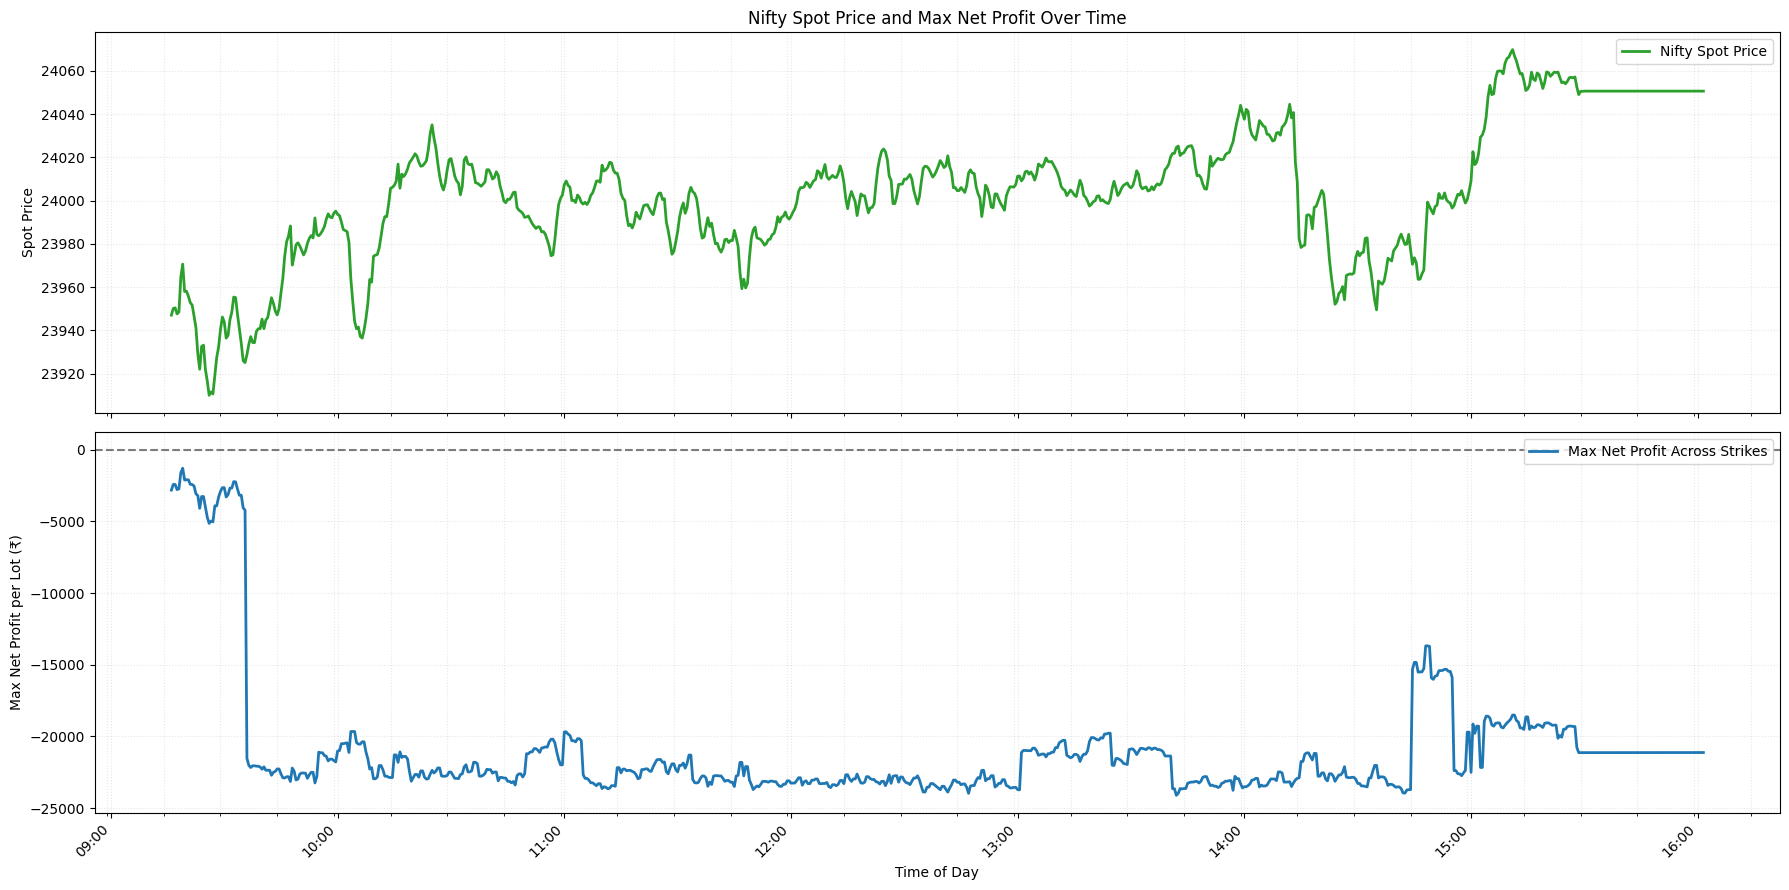

,fetch_time,spot_price,max_profit
0,2026-04-10 09:16:00,23947.000,-2820.298241
1,2026-04-10 09:16:30,23950.075,-2425.196064
2,2026-04-10 09:17:00,23950.375,-2425.183339
3,2026-04-10 09:17:30,23947.600,-2784.641025
4,2026-04-10 09:18:00,23948.450,-2729.574277


In [13]:
# TWO-PANEL VIEW: Spot Price (Top) and Max Net Profit Across Strikes (Bottom)
spot_profit_df = utils.plot_spot_and_max_profit_over_time(
    df[df['both_legs_liquid'] == True],
    min_liquidity=0,
    trading_cost=True,
    per_lot=True,
    figsize=(18, 9),
)
spot_profit_df.head()

In [15]:
# COST BREAKDOWN PIE: Average total_cost in profitable windows
cost_breakdown = utils.plot_avg_cost_breakdown_pie(
    df[df['both_legs_liquid'] == True],
    profitable_only=True,
    min_liquidity=0,
    per_lot=False,
)
cost_breakdown

ValueError: No rows available for the selected filter

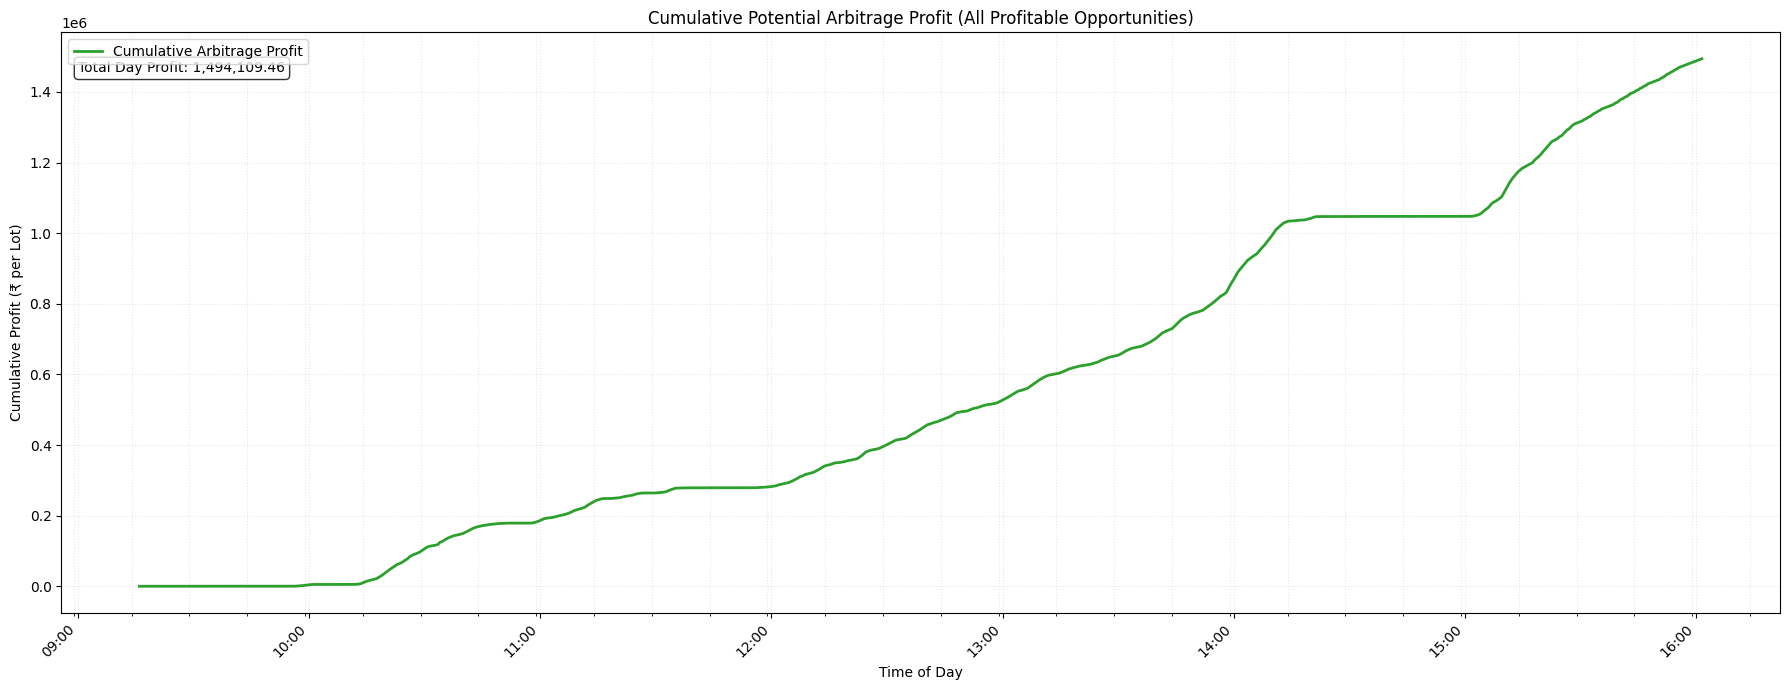

,fetch_time,interval_profit,opportunities_count,cumulative_profit
807,2026-04-10 15:59:30,2096.625174,2,1.485723e+06
808,2026-04-10 16:00:00,2096.654298,2,1.487819e+06
809,2026-04-10 16:00:30,2096.683422,2,1.489916e+06
810,2026-04-10 16:01:00,2096.712545,2,1.492013e+06
811,2026-04-10 16:01:30,2096.741669,2,1.494109e+06


In [18]:
# CUMSUM ARBITRAGE PROFIT: 1 lot at every profitable opportunity across strikes
cumsum_profit_df = utils.plot_cumsum_arbitrage_profit_all_opportunities(
     df,
    require_liquid=False,
    min_liquidity=0,
    per_lot=True,
    figsize=(18, 7),
)
cumsum_profit_df.tail()

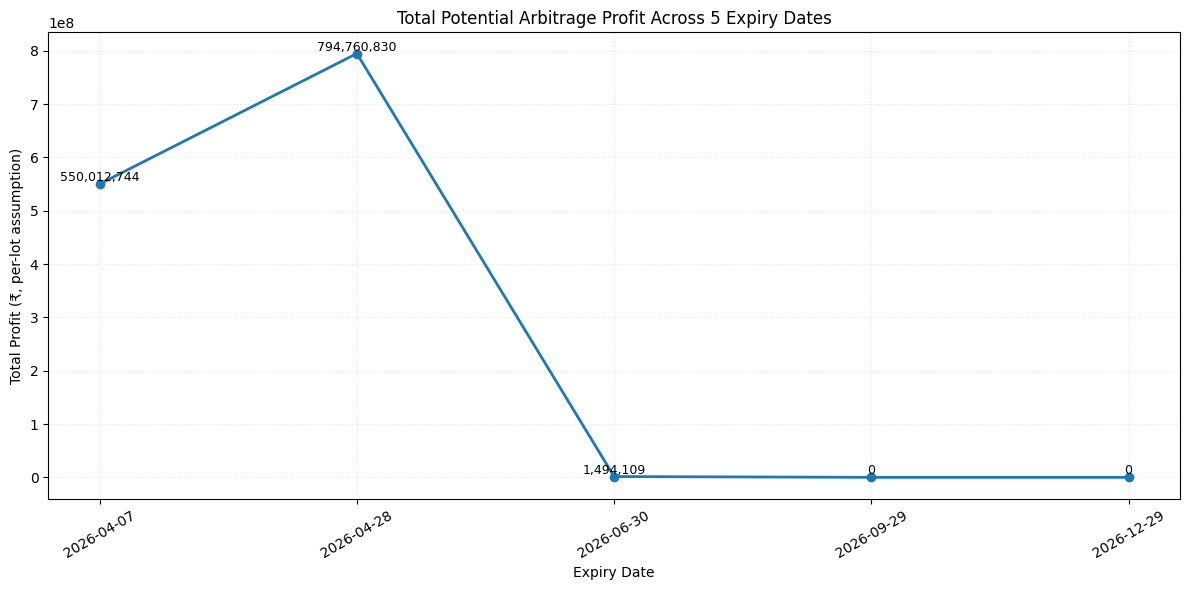

,expiry,total_profit_lot,opportunity_count
0,2026-04-07,5.500127e+08,96224
1,2026-04-28,7.947608e+08,99211
2,2026-06-30,1.494109e+06,1215
3,2026-09-29,0.000000e+00,0
4,2026-12-29,0.000000e+00,0


: 

In [ ]:
# TOTAL PROFIT COMPARISON ACROSS 5 EXPIRY DATES
from pathlib import Path

expiry_files = [
    Path("data/2026-04-06/option_chain_nifty_2026-04-07_full_history.csv"),
    Path("data/2026-04-10/option_chain_nifty_2026-04-28_full_history.csv"),
    Path("data/2026-04-10/option_chain_nifty_2026-06-30_full_history.csv"),
    Path("data/2026-04-10/option_chain_nifty_2026-09-29_full_history.csv"),
    Path("data/2026-04-10/option_chain_nifty_2026-12-29_full_history.csv"),
]

rows = []
for f in expiry_files:
    dfx = load_and_clean_data(str(f))
    dfx = identify_arbitrage(dfx)
    dfx = apply_costs(dfx)

    # Match your strategy assumption: take all profitable opportunities with liquid both legs.
    trades = dfx[(dfx['net_profit_per_unit'] > 0)].copy()
    total_profit_lot = trades['net_profit_per_lot'].sum()

    rows.append({
        'expiry': dfx['expiry'].iloc[0].date(),
        'total_profit_lot': total_profit_lot,
        'opportunity_count': len(trades),
    })

profit_by_expiry = pd.DataFrame(rows).sort_values('expiry').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(
    profit_by_expiry['expiry'].astype(str),
    profit_by_expiry['total_profit_lot'],
    marker='o',
    linewidth=2,
    color='tab:blue',
)

for i, val in enumerate(profit_by_expiry['total_profit_lot']):
    ax.text(i, val, f"{val:,.0f}", ha='center', va='bottom', fontsize=9)

ax.set_title('Total Potential Arbitrage Profit Across 5 Expiry Dates')
ax.set_xlabel('Expiry Date')
ax.set_ylabel('Total Profit (₹, per-lot assumption)')
ax.grid(True, linestyle=':', alpha=0.3)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

profit_by_expiry